# BSDS500 Segmentation with Belief Propagation

This notebook previews data and runs the BSDS500 BP experiment script.

In [1]:
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / 'datasets').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'datasets').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets.bsds500_loader import load_bsds500_dataset

print(f'PROJECT_ROOT = {PROJECT_ROOT}')


PROJECT_ROOT = /mnt/D/mva_P2/GRM/belief_propagation


Using BSDS500 path: /mnt/D/mva_P2/GRM/belief_propagation/data/BSDS500
Loaded 3 samples


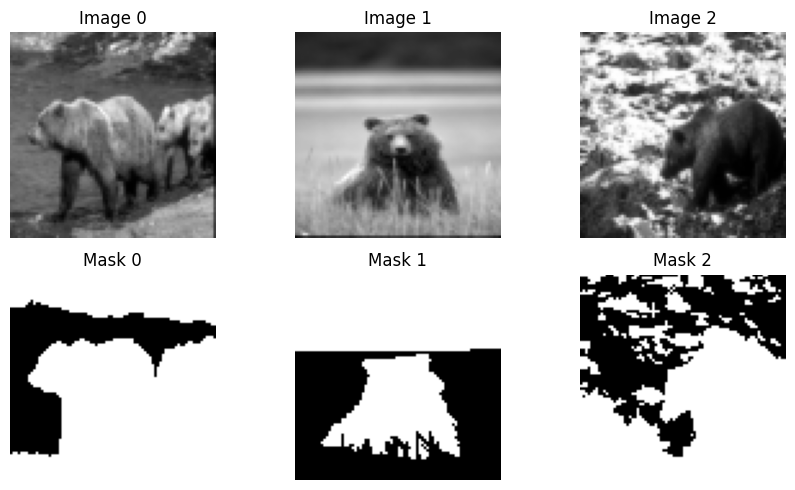

In [2]:
# Auto-detect BSDS500 root in common locations, then load a preview subset.
candidates = [
    PROJECT_ROOT / 'data' / 'BSDS500',
    PROJECT_ROOT.parent / 'data' / 'BSDS500',
    Path('/tmp/bp_demo_data/BSDS500'),
]

def looks_like_bsds(path: Path) -> bool:
    return (path / 'data' / 'images').exists() or (path / 'images').exists()

bsds_path = next((p for p in candidates if looks_like_bsds(p)), None)
if bsds_path is None:
    print('No BSDS500 dataset found in common locations.')
    print('Checked:')
    for p in candidates:
        print('  -', p)
    raise FileNotFoundError(
        'Set `bsds_path` manually to your BSDS500 root (folder containing data/images and data/groundTruth).'
    )

print(f'Using BSDS500 path: {bsds_path}')
images, masks = load_bsds500_dataset(bsds_path, max_images=3, resize=(80, 80))
print(f'Loaded {len(images)} samples')

n_show = min(3, len(images))
if n_show == 0:
    raise RuntimeError('No image/mask pairs loaded. Check your dataset structure.')

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 5), squeeze=False)
for i in range(n_show):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Mask {i}')
    axes[1, i].axis('off')
plt.tight_layout()


In [3]:
# Run the full experiment (edit arguments if needed).
results_dir = PROJECT_ROOT / 'results' / 'segmentation' / 'bsds500'
script_path = PROJECT_ROOT / 'experiments' / 'segmentation_bsds500.py'
print(f'Running: {script_path}')
print(f'Writing results to: {results_dir}')
!python {script_path} --data-path {bsds_path} --max-images 10 --resize 80 80 --results-dir {results_dir}


Running: /mnt/D/mva_P2/GRM/belief_propagation/experiments/segmentation_bsds500.py
Writing results to: /mnt/D/mva_P2/GRM/belief_propagation/results/segmentation/bsds500
[1/10] IoU=0.2194 Acc=0.4134 Runtime=17.36s Iter=30 Converged=False
[2/10] IoU=0.0893 Acc=0.2512 Runtime=16.51s Iter=30 Converged=False
[3/10] IoU=0.1260 Acc=0.1428 Runtime=14.66s Iter=30 Converged=False
[4/10] IoU=0.0800 Acc=0.3283 Runtime=16.20s Iter=30 Converged=False
[5/10] IoU=0.1070 Acc=0.3444 Runtime=15.91s Iter=30 Converged=False
[6/10] IoU=0.0154 Acc=0.4814 Runtime=18.08s Iter=30 Converged=False
[7/10] IoU=0.2703 Acc=0.8975 Runtime=11.53s Iter=20 Converged=True
[8/10] IoU=0.1227 Acc=0.3766 Runtime=16.26s Iter=30 Converged=False
[9/10] IoU=0.1719 Acc=0.6583 Runtime=12.20s Iter=21 Converged=True
[10/10] IoU=0.3318 Acc=0.4891 Runtime=16.90s Iter=30 Converged=False

BSDS500 experiment summary
Images: 10
Mean IoU: 0.1534
Mean accuracy: 0.4383
Mean runtime (s): 15.560
Mean iterations: 28.10
Convergence rate: 0.200


In [4]:
# Load summary from the configured results directory; fallback to latest summary if missing.
search_roots = []
if 'results_dir' in globals():
    search_roots.append(Path(results_dir))
search_roots.extend([
    PROJECT_ROOT / 'results' / 'segmentation',
    Path.cwd() / 'results' / 'segmentation',
    PROJECT_ROOT / 'notebooks' / 'results' / 'segmentation',
])

summary_path = None
for root in search_roots:
    candidate = root / 'bsds500' / 'summary.json'
    if candidate.exists():
        summary_path = candidate
        break

if summary_path is None:
    all_summaries = []
    for root in search_roots:
        if root.exists():
            all_summaries.extend(root.rglob('summary.json'))
    all_summaries = sorted(set(all_summaries), key=lambda p: p.stat().st_mtime, reverse=True)
    if not all_summaries:
        raise FileNotFoundError('No segmentation summary.json found under known results directories.')
    summary_path = all_summaries[0]

print(f'Using summary: {summary_path}')
with summary_path.open() as f:
    summary = json.load(f)
summary

print('Interpretation:')
print(f"- Mean IoU closer to 1 is better: {summary['mean_iou']:.3f}")
print(f"- Mean pixel accuracy closer to 1 is better: {summary['mean_accuracy']:.3f}")
print(f"- Convergence rate is fraction of images where BP hit tolerance: {summary['convergence_rate']:.3f}")


Using summary: /mnt/D/mva_P2/GRM/belief_propagation/results/segmentation/bsds500/summary.json
Interpretation:
- Mean IoU closer to 1 is better: 0.153
- Mean pixel accuracy closer to 1 is better: 0.438
- Convergence rate is fraction of images where BP hit tolerance: 0.200
